In [72]:
import numpy as np

class DirectLattice:
    def __init__(self, a1, a2, a3):
        self.a1 = np.array(a1, dtype = float)
        self.a2 = np.array(a2, dtype = float)
        self.a3 = np.array(a3, dtype = float)

    @property
    def volume(self):
        return np.dot(self.a1, np.cross(self.a2, self.a3))

class ReciprocalLattice:
    def __init__(self, b1, b2, b3):
        self.b1 = np.array(b1, dtype = float)
        self.b2 = np.array(b2, dtype = float)
        self.b3 = np.array(b3, dtype = float)
 
def get_kronecker_delta(i: int, j: int) -> int:
    if i == j:
        return 0    
    else:
        return 1
    
def get_reciprocal_lattice(R: DirectLattice) -> ReciprocalLattice:
    V = np.dot(R.a1, np.cross(R.a2, R.a3))
    b1 = 2 * np.pi * np.cross(R.a2, R.a3) / np.dot(R.a1, np.cross(R.a2, R.a3))
    b2 = 2 * np.pi * np.cross(R.a3, R.a1) / np.dot(R.a1, np.cross(R.a2, R.a3))
    b3 = 2 * np.pi * np.cross(R.a1, R.a2) / np.dot(R.a1, np.cross(R.a2, R.a3))

    return ReciprocalLattice(b1, b2, b3)



In [73]:
a1 = np.array([1,0,0])
a2 = np.array([0,1,0])
a3 = np.array([0,0,1])
A = DirectLattice(a1=a1, a2=a2, a3=a3)

A = DirectLattice(
    a1=np.array([1,0,0]),
    a2=np.array([0,1,0]),
    a3=np.array([0,0,1]),
)

print(type(A))
print(A.a1)
print(A.a2)
print(A.a3)

B = get_reciprocal_lattice(R = A)
print(B.b1)
print(B.b2)
print(B.b3)

<class '__main__.DirectLattice'>
[1. 0. 0.]
[0. 1. 0.]
[0. 0. 1.]
[6.28318531 0.         0.        ]
[0.         6.28318531 0.        ]
[0.         0.         6.28318531]


In [39]:
import numpy as np
import math
z = 1 + 2j
print(f"Re(z):{z.real}")
print(f"Im(z):{z.imag}")
print(f"abs(z):{abs(z)}")
print(math.sqrt(5))
print(f"z.conjugate:{z.conjugate()}")


Re(z):1.0
Im(z):2.0
abs(z):2.23606797749979
2.23606797749979
z.conjugate:(1-2j)


In [30]:
def convert_degrees_to_radians(angle_deg):
    return angle_deg * np.pi/180

def get_lattice_vectors_from_conventional_cell_parameters(
    a, b, c, alpha, beta, gamma):
    """
    a (float): in Angstroms
    b (float): in Angstroms
    c (float): in Angstroms
    alpha (float): in degrees
    beta (float): in degrees
    gamma (float): in degrees
    """

    # convert angles to radians
    alpha_rad = convert_degrees_to_radians(angle_deg=alpha_deg)
    beta_rad = convert_degrees_to_radians(angle_deg=beta_deg)
    gamma_rad = convert_degrees_to_radians(angle_deg=gamma_deg)

    a11 = a
    a12 = 0
    a13 = 0
    a21 = b * np.cos(gamma_rad)
    a22 = b * np.sin(gamma_rad)
    a23 = 0
    a31 = c * np.cos(beta_rad)
    a32 = c * (np.cos(alpha_rad) - np.cos(beta_rad)*np.cos(gamma_rad))/np.sin(gamma_rad)
    a33 = c * np.sqrt(
        1 
        - (np.cos(alpha_rad))**2 
        - (np.cos(beta_rad))**2 
        - (np.cos(gamma_rad))**2
        + 2 * np.cos(alpha_rad) * np.cos(beta_rad) * np.cos(gamma_rad) 
        ) / np.sin(gamma_rad)

    a1 = np.array([a11, a12, a13])
    a2 = np.array([a21, a22, a23])
    a3 = np.array([a31, a32, a33])

    return a1, a2, a3

a1, a2, a3 = get_lattice_vectors_from_conventional_cell_parameters(
    a = 1.0, b = 1.0, c = 1.0,
    alpha = 90, beta = 90, gamma = 90)
print(a1)
print(a2)
print(a3)

[1. 0. 0.]
[6.123234e-17 1.000000e+00 0.000000e+00]
[6.123234e-17 6.123234e-17 1.000000e+00]


In [37]:
R = DirectLattice(a1 = a1, a2 = a2, a3 = a3)
print(f"R.a1:{R.a1}")
print(f"R.a2:{R.a2}")
print(f"R.a3:{R.a3}")

b1 = 2 * np.pi * np.cross(R.a2, R.a3) / np.dot(R.a1, np.cross(R.a2, R.a3))
b2 = 2 * np.pi * np.cross(R.a3, R.a1) / np.dot(R.a1, np.cross(R.a2, R.a3))
b3 = 2 * np.pi * np.cross(R.a1, R.a2) / np.dot(R.a1, np.cross(R.a2, R.a3))

print(f"b1:{b1}")
print(f"b2:{b2}")
print(f"b3:{b3}")

G = get_reciprocal_lattice(R=R)
assert isinstance(G, ReciprocalLattice)
print(f"G.b1:{G.b1}")
print(f"G.b2:{G.b2}")
print(f"G.b3:{G.b3}")


R.a1:[1. 0. 0.]
R.a2:[6.123234e-17 1.000000e+00 0.000000e+00]
R.a3:[6.123234e-17 6.123234e-17 1.000000e+00]
b1:[ 6.28318531e+00 -3.84734139e-16 -3.84734139e-16]
b2:[ 0.00000000e+00  6.28318531e+00 -3.84734139e-16]
b3:[0.         0.         6.28318531]
V:1.0
G.b1:[ 6.28318531e+00 -3.84734139e-16 -3.84734139e-16]
G.b2:[ nan  inf -inf]
G.b3:[0.         0.         6.28318531]


/var/folders/42/g1m9r43x2_v4bkyg4csrsn100000gn/T/ipykernel_9309/1519520963.py:29: RuntimeWarning: divide by zero encountered in divide
  b2 = 2 * np.pi * np.cross(R.a3, R.a1) / np.dot(R.a1, np.cross(R.a3, R.a1))
/var/folders/42/g1m9r43x2_v4bkyg4csrsn100000gn/T/ipykernel_9309/1519520963.py:29: RuntimeWarning: invalid value encountered in divide
  b2 = 2 * np.pi * np.cross(R.a3, R.a1) / np.dot(R.a1, np.cross(R.a3, R.a1))


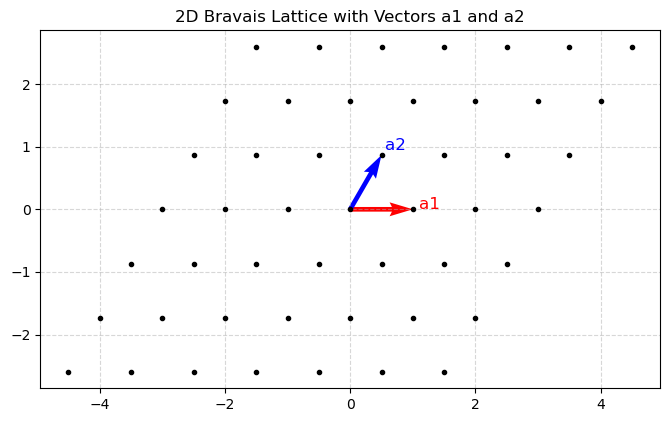

In [55]:
# drawing vectors
import matplotlib.pyplot as plt

# Define lattice vectors
a1 = np.array([1.0, 0.0])
a2 = np.array([0.5, np.sqrt(3)/2])

# generate lattice points
n1_lo = -3
n1_hi = 3
n2_lo = -3
n2_hi = 3
n1_arr = np.linspace(n1_lo, n1_hi, abs(n1_lo) + n1_hi + 1)
n2_arr = np.linspace(n2_lo, n2_hi, abs(n2_lo) + n2_hi + 1)

points = []
for n1 in n1_arr:
    for n2 in n2_arr:
        point = n1 * a1 + n2 * a2
        points.append(point)

points = np.array(points)

# create plot
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect('equal')

# plot lattice points
ax.plot(points[:,0], points[:,1], 'ko', markersize=3)

# plot lattice vectors
origin = np.array([0,0])
ax.quiver(*origin, *a1, angles='xy', scale_units='xy', scale=1, color='r', label='a1')
ax.quiver(*origin, *a2, angles='xy', scale_units='xy', scale=1, color='b', label='a2')
# Add labels to lattice vectors
ax.text(*(a1 * 1.1), 'a1', color='r', fontsize=12)
ax.text(*(a2 * 1.1), 'a2', color='b', fontsize=12)

# Add grid and title
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title('2D Bravais Lattice with Vectors a1 and a2')

plt.show()

# Calculating the reciprocal lattice vectors in 2D

$$
    \mathbf{b}_1 
    = 
    2 \pi \frac{\hat{\mathbf{z}} \times \mathbf{a}_2}
               {\mathbf{a}_1 \cdot (\hat{\mathbf{z}} \times \mathbf{a}_2)}
$$
and
$$
    \mathbf{b}_2 
    = 2 \pi \frac{\hat{\mathbf{z}} \times \mathbf{a}_1}
                 {\mathbf{a}_2 \cdot (\hat{\mathbf{z}} \times \mathbf{a}_1)}

$$
where $\hat{\mathbf{z}} = [0,0,1]$ is unit vector in the out of plane direction for 2D direction.


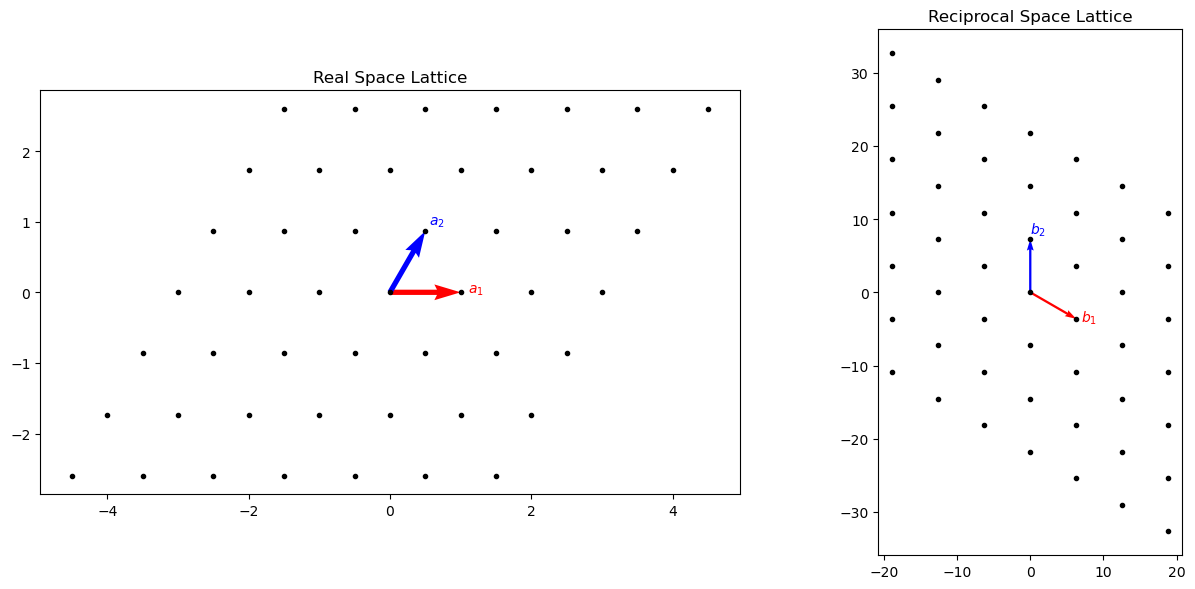

In [67]:
# Visualization of reciprocal lattice vectors
a1 = np.array([1.0, 0.0])
a2 = np.array([0.5, np.sqrt(3)/2])

# cast into 3D
a1_3d = np.array([a1[0], a1[1], 0.])
a2_3d = np.array([a2[0], a2[1], 0.])
z_hat = np.array([0., 0., 1.])

b1 = 2 * np.pi * np.cross(z_hat, a2_3d)[:2] / np.dot(a1, np.cross(z_hat, a2_3d)[:2])
b2 = 2 * np.pi * np.cross(z_hat, a1_3d)[:2] / np.dot(a2, np.cross(z_hat, a1_3d)[:2])

# generate lattice points
n1_lo = -3
n1_hi = 3
n2_lo = -3
n2_hi = 3
n1_arr = np.linspace(n1_lo, n1_hi, abs(n1_lo) + n1_hi + 1)
n2_arr = np.linspace(n2_lo, n2_hi, abs(n2_lo) + n2_hi + 1)


R_points = []
for n1 in n1_arr:
    for n2 in n2_arr:
        R_point = n1*a1 + n2*a2
        R_points.append(R_point)
R_points = np.array(R_points)

G_points = []
for n1 in n1_arr:
    for n2 in n2_arr:
        G_point = n1*b1 + n2*b2
        G_points.append(G_point)
G_points = np.array(G_points)

fig, ax = plt.subplots(1,2,figsize=(14,6))

# plot real space lattice
ax[0].set_title("Real Space Lattice")
ax[0].set_aspect('equal')
ax[0].plot(R_points[:,0], R_points[:,1],'ko', markersize=3)
ax[0].quiver(*[0,0], *a1, scale=1, scale_units='xy', angles='xy', color='r', label="$a_1$")
ax[0].quiver(*[0,0], *a2, scale=1, scale_units='xy', angles='xy', color='b', label="$a_2$")
ax[0].text(*(a1 * 1.1), '$a_1$', color='r')
ax[0].text(*(a2 * 1.1), '$a_2$', color='b')

ax[1].set_title("Reciprocal Space Lattice")
ax[1].set_aspect('equal')
ax[1].plot(G_points[:,0], G_points[:,1],'ko', markersize=3)
ax[1].quiver(*[0,0], *b1, scale=1, scale_units='xy', angles='xy', color='r', label="$b_1$")
ax[1].quiver(*[0,0], *b2, scale=1, scale_units='xy', angles='xy', color='b', label="$b_2$")
ax[1].text(*(b1 * 1.1), '$b_1$', color='r')
ax[1].text(*(b2 * 1.1), '$b_2$', color='b')

plt.tight_layout()
plt.show()